# 03 — Carrier Analysis (Block B)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block B questions: margin by carrier, base vs additional costs, price variability, concentration risk, substitution opportunities, and weight discrepancies.

**Requires:** `01_preparacion.ipynb` to have been run first.

In [8]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")

PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()

print(f"matched: {len(matched):,} rows | carriers: {matched['carrier'].unique()}")

matched: 244,149 rows | carriers: <ArrowStringArray>
['Correos', 'Correos Express', 'UPS']
Length: 3, dtype: str


---
## B1 — Margin by carrier

Which carrier generates the most / least margin for REVER?
Total margin and average margin per shipment ranked by carrier.

        carrier  shipments  total_margin  avg_margin_eur  margin_pct_total
            UPS     115898   431298.7158        3.721365         26.845798
        Correos      98721    14275.8400        0.144608          4.229251
Correos Express      29530    -1823.2600       -0.061743         -1.515366


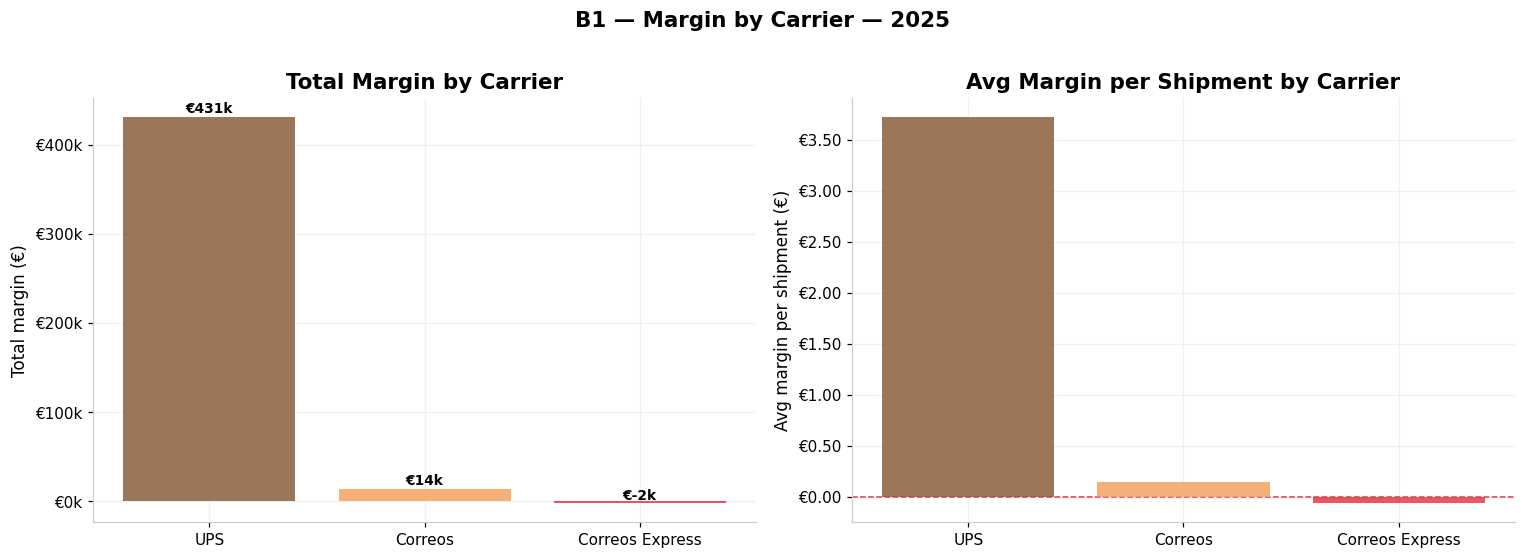

In [9]:
# ── B1: Margin by carrier ─────────────────────────────────────────────────────
carrier_margin = (
    matched.groupby("carrier")
    .agg(
        shipments      = ("tracking_id",       "count"),
        total_revenue  = ("rever_revenue_net", "sum"),
        total_cost     = ("carrier_cost_net",  "sum"),
        total_margin   = ("margin_eur",        "sum"),
        avg_margin_eur = ("margin_eur",        "mean"),
        median_margin  = ("margin_pct",        "median"),
    )
    .reset_index()
    .sort_values("total_margin", ascending=False)
)
carrier_margin["margin_pct_total"] = carrier_margin["total_margin"] / carrier_margin["total_revenue"] * 100
print(carrier_margin[["carrier", "shipments", "total_margin", "avg_margin_eur", "margin_pct_total"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: total margin by carrier
colors = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in carrier_margin["carrier"]]
axes[0].bar(carrier_margin["carrier"], carrier_margin["total_margin"],
            color=colors, alpha=0.85, zorder=3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[0].set_title("Total Margin by Carrier")
axes[0].set_ylabel("Total margin (€)")
for i, row in enumerate(carrier_margin.itertuples()):
    axes[0].text(i, row.total_margin + abs(carrier_margin["total_margin"].max()) * 0.01,
                 f"€{row.total_margin/1_000:.0f}k", ha="center", fontsize=9, fontweight="bold")

# Right: avg margin per shipment
axes[1].bar(carrier_margin["carrier"], carrier_margin["avg_margin_eur"],
            color=colors, alpha=0.85, zorder=3)
axes[1].axhline(0, color=PALETTE["negative"], linewidth=1, linestyle="--")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
axes[1].set_title("Avg Margin per Shipment by Carrier")
axes[1].set_ylabel("Avg margin per shipment (€)")

fig.suptitle("B1 — Margin by Carrier — 2025", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## B2 — Base cost vs additional cost by carrier

`logistic_cost` is the base tariff REVER charges. `custom_cost` is the additional/personalised surcharge.
Comparing carrier invoiced cost against these two components reveals which carriers are expensive in base vs surcharges.

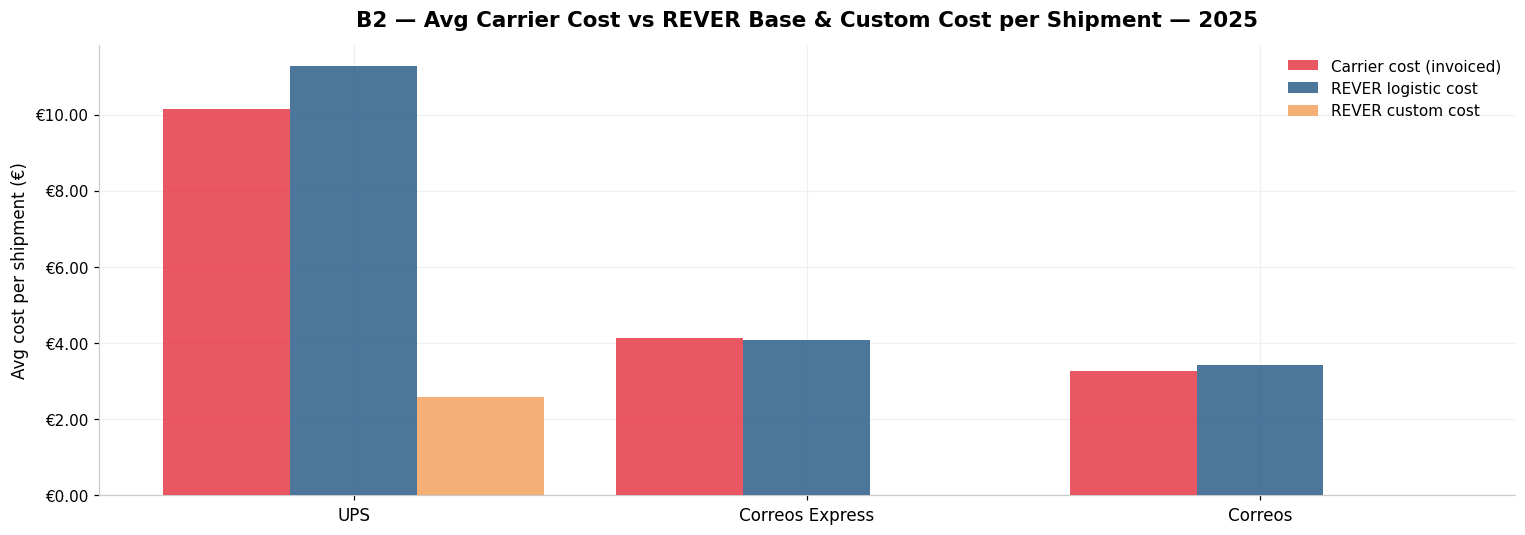

In [10]:
# ── B2: Base cost (logistic_cost) vs custom cost by carrier ──────────────────
b2 = (
    matched.groupby("carrier")
    .agg(
        avg_carrier_cost  = ("carrier_cost_net",    "mean"),
        avg_logistic_cost = ("rever_logistic_cost", "mean"),
        avg_custom_cost   = ("rever_custom_cost",   "mean"),
    )
    .reset_index()
    .sort_values("avg_carrier_cost", ascending=False)
)

x = range(len(b2))
w = 0.28

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar([i - w for i in x], b2["avg_carrier_cost"],  width=w, label="Carrier cost (invoiced)", color=PALETTE["negative"], alpha=0.85, zorder=3)
ax.bar([i      for i in x], b2["avg_logistic_cost"], width=w, label="REVER logistic cost",    color=PALETTE["primary"],  alpha=0.85, zorder=3)
ax.bar([i + w for i in x], b2["avg_custom_cost"],   width=w, label="REVER custom cost",       color=PALETTE["accent"],   alpha=0.85, zorder=3)

ax.set_xticks(list(x))
ax.set_xticklabels(b2["carrier"], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
ax.set_ylabel("Avg cost per shipment (€)")
ax.legend()
ax.set_title("B2 — Avg Carrier Cost vs REVER Base & Custom Cost per Shipment — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## B3 — Price variability by carrier

How consistent is each carrier's cost per shipment? High standard deviation = unpredictable pricing = operational risk.
Box plot shows the distribution of carrier cost per shipment within each carrier.

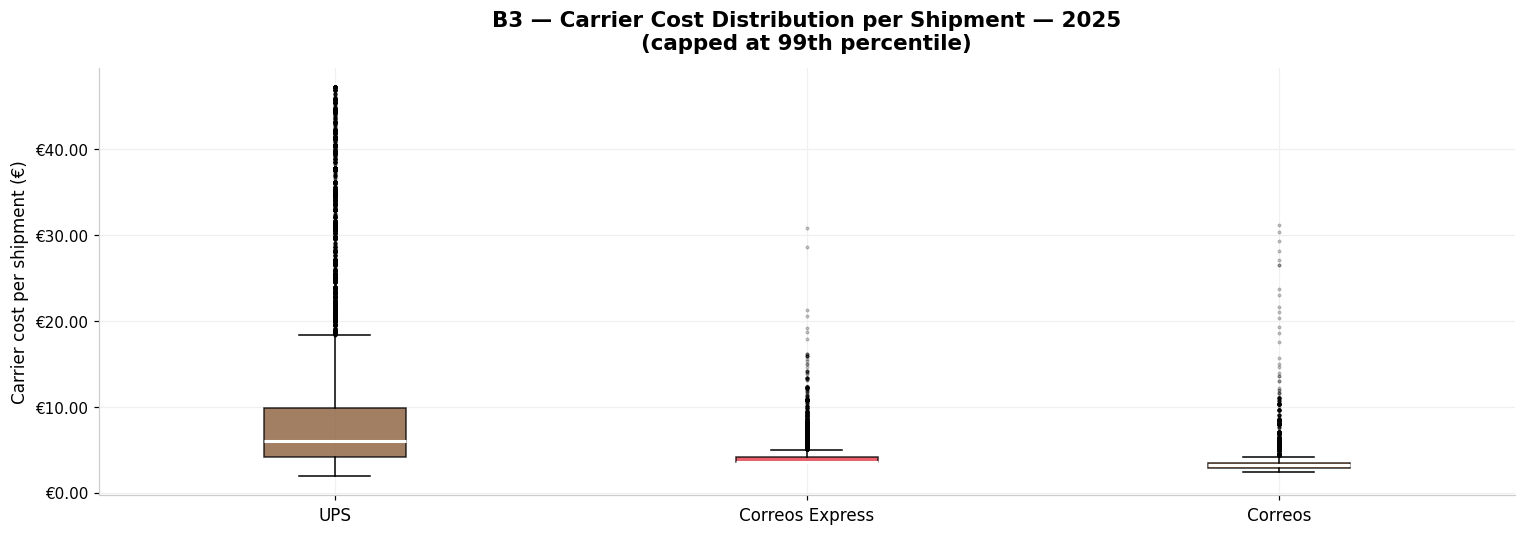

In [11]:
# ── B3: Cost variability by carrier (box plot) ───────────────────────────────
# Cap at 99th percentile to avoid extreme outliers dominating the axis
cap = matched["carrier_cost_net"].quantile(0.99)
b3  = matched[matched["carrier_cost_net"] <= cap].copy()
carrier_order = b3.groupby("carrier")["carrier_cost_net"].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
data_by_carrier = [b3.loc[b3["carrier"] == c, "carrier_cost_net"].values for c in carrier_order]
bp = ax.boxplot(data_by_carrier, patch_artist=True, medianprops={"color": "white", "linewidth": 2},
                showfliers=True, flierprops={"marker": ".", "markersize": 3, "alpha": 0.3})

for patch, c in zip(bp["boxes"], carrier_order):
    patch.set_facecolor(CARRIER_COLORS.get(c, PALETTE["neutral"]))
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(carrier_order) + 1))
ax.set_xticklabels(carrier_order, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
ax.set_ylabel("Carrier cost per shipment (€)")
ax.set_title("B3 — Carrier Cost Distribution per Shipment — 2025\n(capped at 99th percentile)", pad=12)
plt.tight_layout()
plt.show()

---
## B4 — Carrier concentration

What % of shipments and total cost is handled by each carrier?
A carrier with >60-70% share represents a concentration risk.

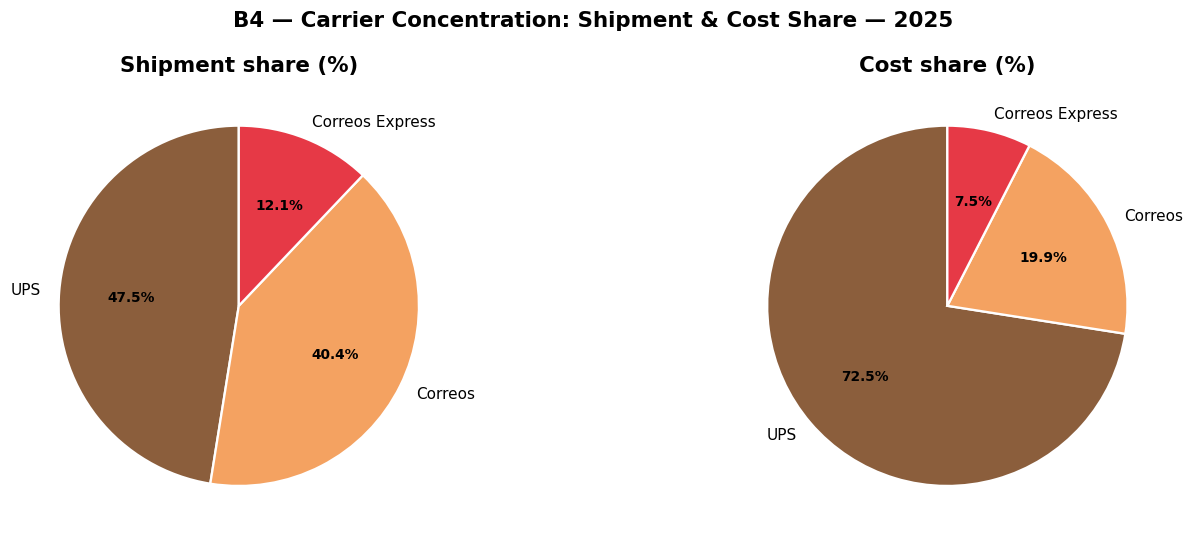

In [12]:
# ── B4: Carrier concentration ─────────────────────────────────────────────────
conc = (
    matched.groupby("carrier")
    .agg(shipments=("tracking_id", "count"), total_cost=("carrier_cost_net", "sum"))
    .reset_index()
)
conc["ship_pct"] = conc["shipments"] / conc["shipments"].sum() * 100
conc["cost_pct"] = conc["total_cost"] / conc["total_cost"].sum() * 100
conc = conc.sort_values("ship_pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
colors = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in conc["carrier"]]

for ax, col, title in zip(axes, ["ship_pct", "cost_pct"], ["Shipment share (%)", "Cost share (%)"]):
    wedges, texts, autotexts = ax.pie(
        conc[col], labels=conc["carrier"], colors=colors,
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 10},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight("bold")
    ax.set_title(title)

fig.suptitle("B4 — Carrier Concentration: Shipment & Cost Share — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## B5 & B6 — Substitution opportunities & weight discrepancy

**B5:** Avg cost by carrier × destination country. Reveals where a carrier is systematically more expensive than others for the same route.

**B6:** Billed weight vs actual weight by carrier. If billed weight is consistently higher than actual, the carrier is overcharging via rounding or minimum weight rules.

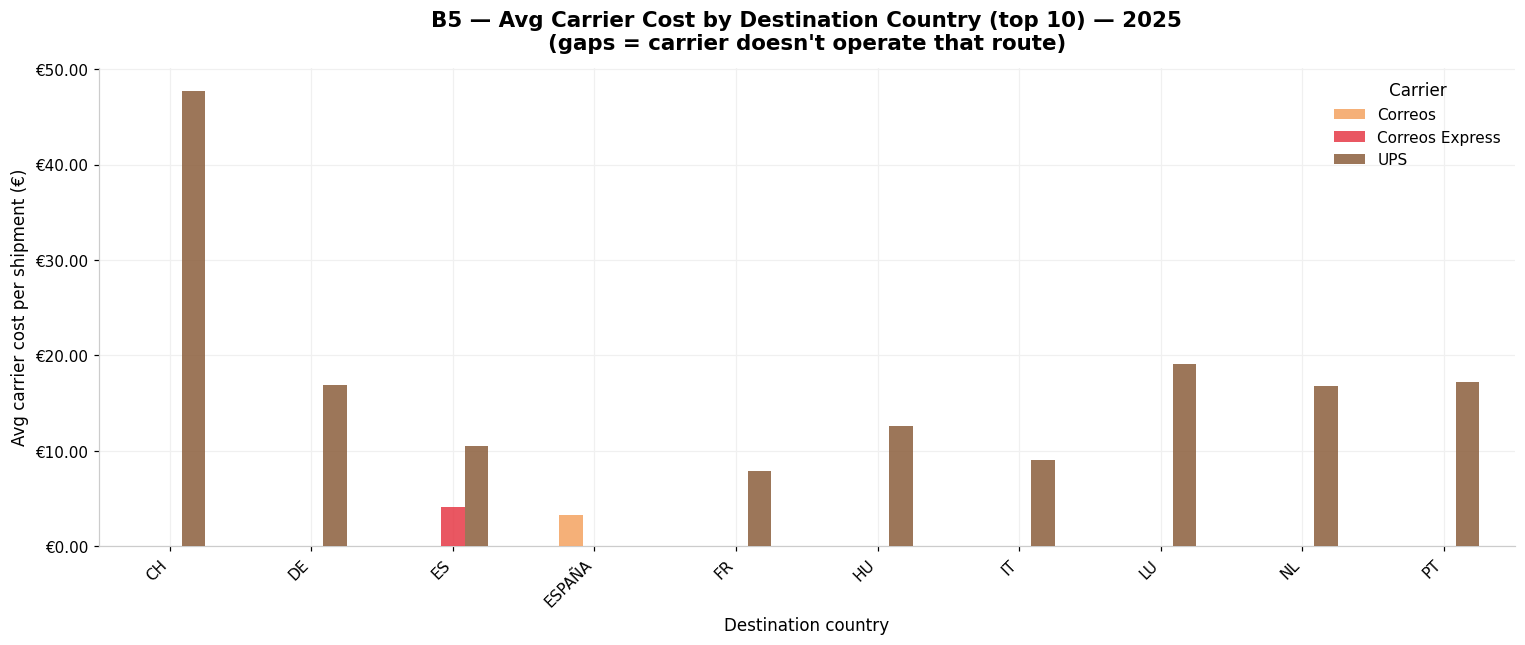

In [13]:
# ── B5: Avg cost by carrier × destination country (top 10 countries) ─────────
top_countries = (
    matched.groupby("destination_country")["tracking_id"].count()
    .sort_values(ascending=False).head(10).index.tolist()
)
b5 = (
    matched[matched["destination_country"].isin(top_countries)]
    .groupby(["destination_country", "carrier"])["carrier_cost_net"]
    .mean()
    .reset_index()
    .pivot(index="destination_country", columns="carrier", values="carrier_cost_net")
)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))
b5.plot(kind="bar", ax=ax, color=[CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in b5.columns],
        alpha=0.85, zorder=3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
ax.set_xlabel("Destination country")
ax.set_ylabel("Avg carrier cost per shipment (€)")
ax.set_xticklabels(b5.index, rotation=45, ha="right")
ax.legend(title="Carrier", loc="upper right")
ax.set_title("B5 — Avg Carrier Cost by Destination Country (top 10) — 2025\n(gaps = carrier doesn't operate that route)", pad=12)
plt.tight_layout()
plt.show()

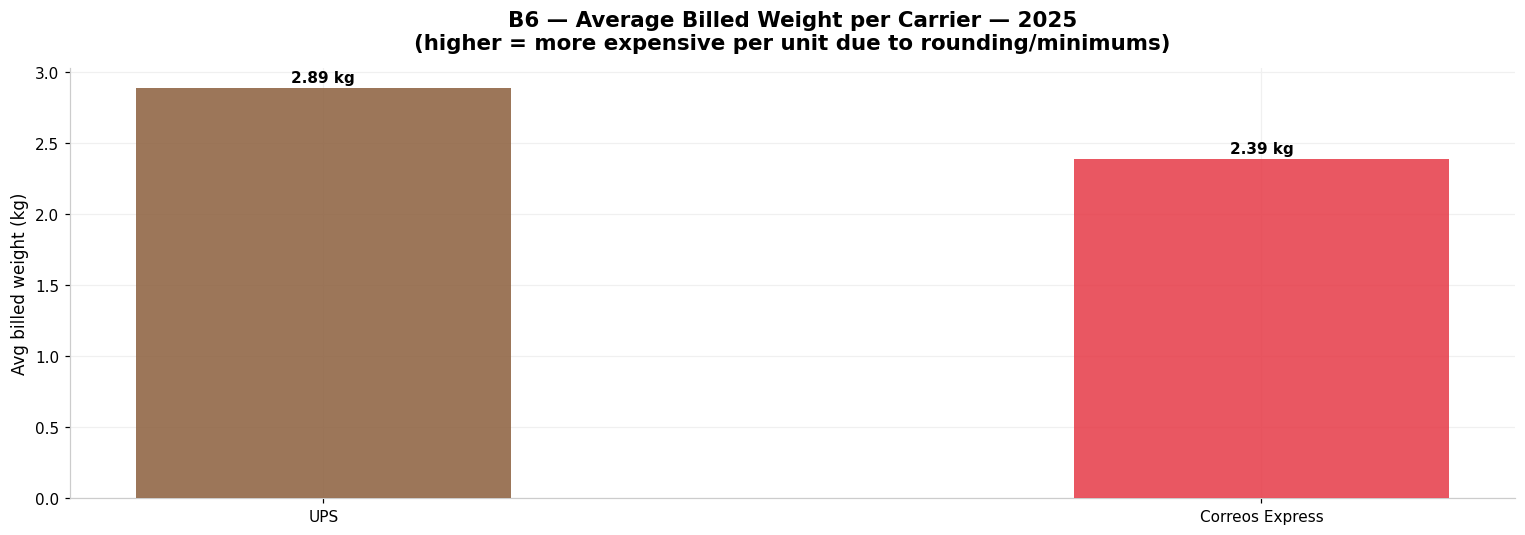

In [14]:
# ── B6: Billed weight vs actual weight by carrier ────────────────────────────
# Only carriers that have both columns: UPS and GLS have actual + billed weight.
weight_df = matched.dropna(subset=["billed_weight_kg"]).copy()
weight_df = weight_df[weight_df["billed_weight_kg"] > 0]

# UPS also has actual_weight_kg — check if available in merged
has_actual = "actual_weight_kg" in weight_df.columns

b6 = (
    weight_df.groupby("carrier")
    .agg(avg_billed=("billed_weight_kg", "mean"))
    .reset_index()
    .sort_values("avg_billed", ascending=False)
)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
colors_b6 = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in b6["carrier"]]
bars = ax.bar(b6["carrier"], b6["avg_billed"], color=colors_b6, alpha=0.85, zorder=3, width=0.4)

for bar, row in zip(bars, b6.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{row.avg_billed:.2f} kg", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Avg billed weight (kg)")
ax.set_title("B6 — Average Billed Weight per Carrier — 2025\n(higher = more expensive per unit due to rounding/minimums)", pad=12)
plt.tight_layout()
plt.show()

---
## B7 — Correos Express: why is it loss-making?

CE has a net margin of -1.5% (-€1,823). The question is not only that CE loses money —
it's **why REVER keeps routing to CE** and whether there is a viable alternative for each route.
This cell checks: which countries CE serves, whether those routes have a Correos/UPS alternative,
and whether any merchants are exclusively locked into CE.

CE shipments    : 29,530
CE total margin : €-1,823  (-1.5%)
CE loss shipments: 9,014 (30.5%)

CE: top 10 destination countries
                     count  total_margin  avg_margin  avg_cost  avg_revenue
destination_country                                                        
ES                   29530      -1823.26   -0.061743  4.136179     4.074436

Merchants exclusively on Correos Express: 2
                    count  total_margin
stripe_cust_id                         
cus_TOgFQI9Jpy4Uhh      7         -1.56
cus_QCV6hF2AxCeSxI      1          0.92


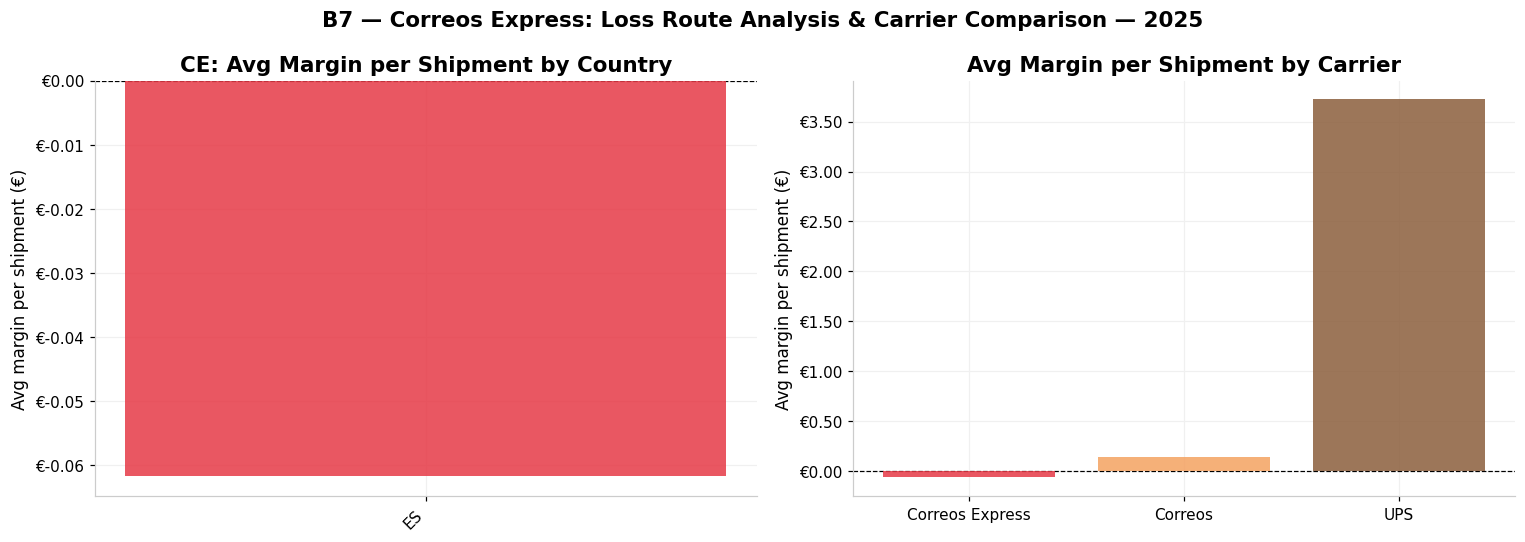

In [15]:
# ── B7: Correos Express — route and merchant dependency analysis ───────────────
ce = matched[matched["carrier"] == "Correos Express"].copy()

print(f"CE shipments    : {len(ce):,}")
print(f"CE total margin : €{ce['margin_eur'].sum():,.0f}  ({ce['margin_eur'].sum()/ce['rever_revenue_net'].sum()*100:.1f}%)")
print(f"CE loss shipments: {(ce['margin_eur'] < 0).sum():,} ({(ce['margin_eur'] < 0).mean()*100:.1f}%)")
print()

# Margin by destination country (top 10 by volume)
ce_country = (
    ce.groupby("destination_country")
    .agg(count=("tracking_id", "count"),
         total_margin=("margin_eur", "sum"),
         avg_margin=("margin_eur", "mean"),
         avg_cost=("carrier_cost_net", "mean"),
         avg_revenue=("rever_revenue_net", "mean"))
    .sort_values("count", ascending=False)
    .head(10)
)
print("CE: top 10 destination countries")
print(ce_country.to_string())
print()

# Merchants exclusively on CE (no Correos or UPS in their history)
merchant_carriers = matched.groupby("stripe_cust_id")["carrier"].apply(set)
ce_only_ids = merchant_carriers[merchant_carriers.apply(lambda s: s == {"Correos Express"})].index
print(f"Merchants exclusively on Correos Express: {len(ce_only_ids)}")
if len(ce_only_ids) > 0:
    ce_only_summary = (
        ce[ce["stripe_cust_id"].isin(ce_only_ids)]
        .groupby("stripe_cust_id")
        .agg(count=("tracking_id", "count"), total_margin=("margin_eur", "sum"))
        .sort_values("total_margin")
    )
    print(ce_only_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: CE avg margin by country
top10 = ce_country.head(10).reset_index()
bar_c = [PALETTE["positive"] if m >= 0 else PALETTE["negative"] for m in top10["avg_margin"]]
axes[0].bar(top10["destination_country"], top10["avg_margin"], color=bar_c, alpha=0.85, zorder=3)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xticklabels(top10["destination_country"], rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
axes[0].set_title("CE: Avg Margin per Shipment by Country")
axes[0].set_ylabel("Avg margin per shipment (€)")

# Right: CE vs all carriers avg margin/shipment
carrier_avg = matched.groupby("carrier")["margin_eur"].mean().reset_index().sort_values("margin_eur")
colors_comp = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in carrier_avg["carrier"]]
axes[1].bar(carrier_avg["carrier"], carrier_avg["margin_eur"], color=colors_comp, alpha=0.85, zorder=3)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
axes[1].set_title("Avg Margin per Shipment by Carrier")
axes[1].set_ylabel("Avg margin per shipment (€)")

fig.suptitle("B7 — Correos Express: Loss Route Analysis & Carrier Comparison — 2025",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()